# Cross-Sectional 12–1 Momentum Strategy

This notebook implements the same workflow **without classes**:

1. Download and clean market data  
2. Compute the 12–1 momentum factor and cross-sectional z-scores  
3. Build portfolio signals, weights, and backtest returns  




## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

## 2. Strategy Inputs

In [2]:
tickers = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META",
    "GOOGL", "JPM", "BAC", "XOM", "CVX",
    "WMT", "COST", "JNJ", "PFE", "MRK",
    "CAT", "HD", "KO", "PEP", "UNH"
]

start_date = "2018-01-01"
end_date = "2026-01-01" 

## 3. Download Raw Data

In [6]:
print(f"Initiating data download for {len(tickers)} tickers...")

try:
    raw_data = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        group_by="ticker",
        auto_adjust=True
    )
except Exception as e:
    raise RuntimeError(f"Failed to fetch data from API: {e}")

Initiating data download for 20 tickers...


[*********************100%***********************]  20 of 20 completed


In [7]:
raw_data

Ticker              HD                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2018-01-02  153.288155  153.699154  151.515190  151.531311  4684700   
2018-01-03  151.507102  152.603111  151.362048  152.321045  4530500   
2018-01-04  153.014108  153.819997  151.885869  153.529877  4047400   
2018-01-05  153.868370  155.165851  153.529898  155.133621  4224800   
2018-01-08  154.505000  156.116778  154.408298  154.762878  3508500   
...                ...         ...         ...         ...      ...   
2025-12-24  337.023037  340.859753  336.592385  339.959290  1368600   
2025-12-26  339.616750  342.611725  339.205691  342.347473  1786900   
2025-12-29  342.562758  342.875965  337.424317  340.066956  3790000   
2025-12-30  338.677149  339.606974  336.416237  338.990356  2392600   
2025-12-31  338.158361  339.342641  336.660874  336.788116  2317500   

Ticker             UNH                                               ...  \
Price             Open        High         Low       Close   Volume  ...   
Date                                                                 ...   
2018-01-02  191.872345  193.113753  190.986856  191.993881  3485000  ...   
2018-01-03  192.393197  194.294386  191.438270  194.007904  2417600  ...   
2018-01-04  194.754558  196.282462  194.606979  194.850052  2749100  ...   
2018-01-05  195.492406  198.843357  195.084387  198.565552  2432800  ...   
2018-01-08  198.044721  198.548234  194.988928  195.119141  2850800  ...   
...                ...         ...         ...         ...      ...  ...   
2025-12-24  320.858767  324.598151  319.803044  323.206970  2842700  ...   
2025-12-26  322.832041  327.459434  321.904587  327.400208  4359300  ...   
2025-12-29  326.472809  329.787940  323.897635  324.548828  4346800  ...   
2025-12-30  325.328246  331.662525  325.111182  327.725800  4432500  ...   
2025-12-31  327.883705  328.880202  325.476276  325.703186  4285200  ...   

Ticker            NVDA                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2018-01-02    4.834377    4.926235    4.802771    4.922531  355616000   
2018-01-03    5.039821    5.276874    5.031179    5.246501  914704000   
2018-01-04    5.327740    5.384287    5.251933    5.274157  583268000   
2018-01-05    5.288972    5.356137    5.212177    5.318851  580124000   
2018-01-08    5.442314    5.555901    5.397373    5.481823  881216000   
...                ...         ...         ...         ...        ...   
2025-12-24  187.711052  188.679871  186.362690  188.380234   65528500   
2025-12-26  189.688640  192.455270  187.770981  190.297897  139740300   
2025-12-29  187.481334  188.530043  185.683524  187.990707  120006100   
2025-12-30  188.010698  188.759785  186.702281  187.311539   97687300   
2025-12-31  189.339079  190.327864  186.262830  186.272812  120100500   

Ticker             JNJ                                               
Price             Open        High         Low       Close   Volume  
Date                                                                 
2018-01-02  109.928776  110.157034  109.188884  109.590309  6842100  
2018-01-03  109.692623  110.731611  109.330544  110.637161  5350500  
2018-01-04  110.550609  111.093722  110.369576  110.629326  4837600  
2018-01-05  110.739534  111.628980  110.416813  111.542397  6158800  
2018-01-08  111.534513  111.770650  110.920562  111.684067  5129800  
...                ...         ...         ...         ...      ...  
2025-12-24  202.739054  204.648346  202.315868  204.490875  2376500  
2025-12-26  204.244839  204.746760  203.437827  204.343262  2316700  
2025-12-29  204.707406  206.154137  204.097225  204.274368  4348900  
2025-12-30  204.225152  204.402310  203.250833  203.634659  3937400  
2025-12

## 4. Extract Close Prices

In [8]:
prices_dict = {}

for ticker in tickers:
    if ticker in raw_data.columns.levels[0]:
        prices_dict[ticker] = raw_data[ticker]["Close"]

daily_prices = pd.DataFrame(prices_dict)
daily_prices.index = pd.to_datetime(daily_prices.index)# need for resampling

daily_prices.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.232376,78.552032,4.922531,59.450500,179.840729,53.154694,85.516029,24.385731,57.811157,87.873611,28.731459,167.986969,109.590309,23.040375,41.296524,131.050797,151.531311,35.024231,89.690910,191.993881
2018-01-03,40.225361,78.917610,5.246501,60.209999,183.062439,54.061569,85.603188,24.304171,58.946575,88.514168,28.982073,170.002930,110.637161,23.211084,41.237766,131.251083,152.321045,34.947308,89.455391,194.007904
2018-01-04,40.412220,79.612190,5.274157,60.479500,182.725388,54.271564,86.829491,24.622248,59.028172,88.238670,29.008307,168.682739,110.629326,23.261671,41.906204,133.053589,153.529877,35.439529,89.896065,194.850052
2018-01-05,40.872322,80.599243,5.318851,61.457001,185.223465,54.991219,86.272064,24.736425,58.980553,88.094009,29.180243,167.478470,111.542397,23.305933,41.862125,135.156555,155.133621,35.431847,90.154335,198.565552
2018-01-08,40.720509,80.681496,5.481823,62.343498,186.640991,55.185364,86.399506,24.565159,59.245720,88.527939,29.611551,168.129669,111.684067,23.046698,41.619732,138.553024,154.762878,35.378006,89.637718,195.119141


## 5. Clean Daily Prices

In [9]:
# Forward-fill only uses information already known in the past.
daily_prices = daily_prices.ffill()

# Remove a stock only if its entire column is missing.
daily_prices = daily_prices.dropna(axis=1, how="all")

print(f"Data cleaning complete. Structured shape: {daily_prices.shape}")

Data cleaning complete. Structured shape: (2011, 20)


## 6. Convert Daily Prices to Month-End Prices

In [10]:
monthly_prices = daily_prices.resample("ME").last()

monthly_prices.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,39.104309,86.832214,6.069515,72.544502,185.263092,58.553825,92.109016,26.098438,59.354507,86.337646,31.065737,173.829758,108.771736,23.419748,43.522213,136.471375,161.903030,36.600864,91.392685,205.554016
2018-02-28,41.770638,86.101501,5.979396,75.622498,176.767715,54.675720,91.973625,26.179991,52.021542,77.854797,26.231031,170.744019,102.885384,23.170864,39.827419,129.638565,146.889359,33.239929,83.362579,196.334503
2018-03-31,39.345802,83.805954,5.722181,72.366997,158.398987,51.368198,87.570053,24.550913,51.245403,79.329552,26.082541,168.534866,101.514969,22.647600,40.360928,123.560410,144.460831,33.696297,83.534767,186.393250
2018-04-30,38.754852,85.871941,5.556884,78.306503,170.502747,50.448944,87.061707,24.493610,53.402073,87.030159,25.933027,176.343109,100.199982,23.362312,43.621243,121.637810,149.777573,33.525608,77.251488,205.903488
2018-05-31,43.991562,91.150269,6.235026,81.481003,190.110535,54.481571,85.645103,23.870340,56.364754,87.220703,24.349955,177.826157,95.460648,23.152197,44.110279,127.999413,152.042389,33.362682,77.429024,210.354370


## 7. Compute Monthly Returns

In [11]:
monthly_returns = (
    monthly_prices
    .pct_change(fill_method=None)
    .dropna(how="all")# all operations with NaN give NaN, this is the reason wwhy first row will be NaN
)

monthly_returns.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2018-02-28,0.068185,-0.008415,-0.014848,0.042429,-0.045856,-0.066231,-0.001470,0.003125,-0.123545,-0.098252,-0.155628,-0.017752,-0.054117,-0.010627,-0.084894,-0.050068,-0.092732,-0.091827,-0.087864,-0.044852
2018-03-31,-0.058051,-0.026661,-0.043017,-0.043049,-0.103914,-0.060493,-0.047879,-0.062226,-0.014920,0.018942,-0.005661,-0.012938,-0.013320,-0.022583,0.013396,-0.046885,-0.016533,0.013729,0.002066,-0.050634
2018-04-30,-0.015019,0.024652,-0.028887,0.082075,0.076413,-0.017895,-0.005805,-0.002334,0.042085,0.097071,-0.005732,0.046330,-0.012954,0.031558,0.080779,-0.015560,0.036804,-0.005066,-0.075218,0.104672
2018-05-31,0.135124,0.061467,0.122036,0.040539,0.115000,0.079935,-0.016271,-0.025446,0.055479,0.002189,-0.061045,0.008410,-0.047299,-0.008994,0.011211,0.052300,0.015121,-0.004860,0.002298,0.021616
2018-06-30,-0.009418,-0.002327,-0.060629,0.043065,0.013244,0.026536,-0.026259,-0.029270,0.018341,0.017136,0.037679,0.054177,0.014379,0.009741,0.027534,-0.106905,0.045832,0.029084,0.085985,0.019452


## 8. Compute 12–1 Momentum

In [13]:
print("Computing cross-sectional 12M-1M Momentum factor signals...")

price_t_minus_1 = monthly_prices.shift(1)
price_t_minus_12 = monthly_prices.shift(12)

momentum_raw = (price_t_minus_1 / price_t_minus_12) - 1.0

factor_scores = momentum_raw.dropna(how="all")

factor_scores.head()

Computing cross-sectional 12M-1M Momentum factor signals...


,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2019-01-31,-0.043731,0.087552,-0.455360,0.035206,-0.298571,-0.116104,-0.141186,-0.215843,-0.186530,-0.098626,-0.105432,0.056332,-0.040811,0.220556,0.329149,-0.205604,-0.125422,0.029369,-0.051136,0.066304
2019-02-28,-0.055397,0.127665,-0.404704,0.136388,-0.065220,0.019902,-0.080711,-0.096778,-0.002583,0.053428,0.089930,0.133071,0.045734,0.210230,0.414816,-0.118018,0.029667,0.152121,0.060886,0.210841
2019-03-31,0.047721,0.248175,-0.331777,0.132996,0.010389,0.086208,-0.026461,-0.011185,0.104096,0.089140,0.132280,0.173065,0.095420,0.264443,0.524791,-0.045583,0.056161,0.070636,0.095419,0.143347
2019-04-30,0.166903,0.282408,-0.199046,0.137038,-0.030872,0.155422,-0.050145,-0.059655,0.083236,0.022658,0.128049,0.241057,0.135381,0.200878,0.453250,-0.043557,0.063672,0.121871,0.255295,0.060579
2019-05-31,0.086012,0.337831,-0.280435,0.182190,0.008447,0.089964,0.115394,0.069466,0.019693,-0.005422,0.266796,0.247936,0.203769,0.158706,0.360070,-0.059060,0.112316,0.180277,0.308625,-0.021440


The signal is

$$
Momentum_{12-1,t} = \frac{P_{t-1}}{P_{t-12}} - 1
$$

The most recent month is skipped.

## 9. Compute Cross-Sectional Z-Scores

In [14]:
mean_t = factor_scores.mean(axis=1)
std_t = factor_scores.std(axis=1)

z_scores = (
    factor_scores
    .sub(mean_t, axis=0)
    .div(std_t, axis=0)
)

z_scores.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2019-01-31,0.109198,0.853390,-2.224173,0.556661,-1.335397,-0.301057,-0.443236,-0.866442,-0.700276,-0.201984,-0.240561,0.676416,0.125748,1.607343,2.222911,-0.808402,-0.353876,0.523573,0.067221,0.732943
2019-02-28,-0.596125,0.512216,-2.711001,0.565032,-0.655600,-0.140232,-0.749388,-0.846665,-0.276364,0.062752,0.283751,0.544948,0.016167,1.012104,2.250770,-0.975262,-0.081108,0.660288,0.107909,1.015806
2019-03-31,-0.282395,0.968781,-2.651099,0.249866,-0.515408,-0.042167,-0.745410,-0.650066,0.069482,-0.023869,0.245398,0.499963,0.015332,1.070317,2.695325,-0.864768,-0.229710,-0.139367,0.015320,0.314476
2019-04-30,0.414485,1.203434,-2.085108,0.210497,-0.936408,0.336066,-1.068050,-1.133008,-0.157001,-0.570771,0.149093,0.920989,0.199173,0.646547,2.370363,-1.023053,-0.290630,0.106897,1.018240,-0.311756
2019-05-31,-0.214740,1.421690,-2.596068,0.410264,-0.718789,-0.189060,-0.023801,-0.322259,-0.645707,-0.808916,0.960073,0.837514,0.550495,0.257655,1.566209,-1.157479,-0.043802,0.397832,1.231893,-0.913005


## 10. Convert Z-Scores to Percentile Ranks

In [17]:
percentile_rank = z_scores.rank(
    axis=1,
    pct=True
)

percentile_rank.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2019-01-31,0.60,0.90,0.05,0.75,0.10,0.40,0.30,0.15,0.25,0.50,0.45,0.80,0.65,0.95,1.0,0.2,0.35,0.70,0.55,0.85
2019-02-28,0.30,0.70,0.05,0.80,0.25,0.40,0.20,0.15,0.35,0.55,0.65,0.75,0.50,0.90,1.0,0.1,0.45,0.85,0.60,0.95
2019-03-31,0.30,0.90,0.05,0.75,0.25,0.45,0.15,0.20,0.65,0.50,0.70,0.85,0.60,0.95,1.0,0.1,0.35,0.40,0.55,0.80
2019-04-30,0.75,0.95,0.05,0.65,0.25,0.70,0.15,0.10,0.45,0.30,0.55,0.85,0.60,0.80,1.0,0.2,0.40,0.50,0.90,0.35
2019-05-31,0.40,0.95,0.05,0.70,0.25,0.45,0.55,0.35,0.30,0.20,0.85,0.80,0.75,0.60,1.0,0.1,0.50,0.65,0.90,0.15


## 11. Select the Top/Worst 20% of Stocks

In [26]:
long_signals = percentile_rank >= 0.80
short_signals = percentile_rank <= 0.20

long_signals.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2019-01-31,False,True,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,True
2019-02-28,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,True,False,True
2019-03-31,False,True,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,True
2019-04-30,False,True,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,True,False
2019-05-31,False,True,False,False,False,False,False,False,False,False,True,True,False,False,True,False,False,False,True,False


`True` means that the stock is selected for that month.  
`False` means that it is not selected.


## 12. Create Equal Weights

In [46]:
number_selected = long_signals.sum(axis=1)

long_weights = long_signals.div(
    number_selected,
    axis=0
)
short_weights = short_signals.div(
    short_signals.sum(axis=1),
    axis=0
)

long_weights.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2019-01-31,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.2,0.0,0.0,0.0,0.0,0.2
2019-02-28,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.2,0.0,0.2
2019-03-31,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.2,0.0,0.0,0.0,0.0,0.2
2019-04-30,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.2,0.2,0.0,0.0,0.0,0.2,0.0
2019-05-31,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.2,0.0,0.0,0.0,0.2,0.0


In [47]:
short_weights.head()

,AAPL,MSFT,NVDA,AMZN,META,GOOGL,JPM,BAC,XOM,CVX,WMT,COST,JNJ,PFE,MRK,CAT,HD,KO,PEP,UNH
Date,,,,,,,,,,,,,,,,,,,,
2019-01-31,0.0,0.0,0.25,0.0,0.25,0.0,0.00,0.25,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.00
2019-02-28,0.0,0.0,0.25,0.0,0.00,0.0,0.25,0.25,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.00
2019-03-31,0.0,0.0,0.25,0.0,0.00,0.0,0.25,0.25,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.00
2019-04-30,0.0,0.0,0.25,0.0,0.00,0.0,0.25,0.25,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.00
2019-05-31,0.0,0.0,0.25,0.0,0.00,0.0,0.00,0.00,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.25


In [ ]:
Now when you long_short_weights = long_weights - short_weights, you will get positiv weights for long, and negative for short

## 13. Backtest the Strategy

In [37]:
long_strategy_returns = (
    long_weights.shift(1) *
    monthly_returns
).sum(axis=1)

long_strategy_returns

Date
2018-02-28    0.000000
2018-03-31    0.000000
2018-04-30    0.000000
2018-05-31    0.000000
2018-06-30    0.000000
                ...   
2025-08-31   -0.010153
2025-09-30    0.018720
2025-10-31    0.030399
2025-11-30   -0.005917
2025-12-31    0.011253
Freq: ME, Length: 95, dtype: float64

The one-month shift is essential:

$$
R_{p,t} = \sum_i w_{i,t-1}R_{i,t}
$$

Weights formed using information available at the end of month \(t-1\) are applied to returns earned during month \(t\).  
This avoids using future information in the backtest.


In [41]:
long_short_weights = (
    long_weights - short_weights
)
long_short_returns = (
    long_short_weights.shift(1) *
    monthly_returns
).sum(axis=1)

## 14. Cumulative Strategy Performance

In [42]:
long_cumulative_strategy = (1 + long_strategy_returns).cumprod()
cumulative_long_short = (
    1 + long_short_returns
).cumprod()

long_cumulative_strategy.tail()

Date
2025-08-31    4.619723
2025-09-30    4.706202
2025-10-31    4.849266
2025-11-30    4.820572
2025-12-31    4.874817
Freq: ME, dtype: float64

In [48]:
cumulative_long_short = (
    1 + long_short_returns
).cumprod()

In [43]:
benchmark_returns = monthly_returns.mean(axis=1)

cumulative_benchmark = (
    1 + benchmark_returns
).cumprod()

In [49]:
comparison = pd.DataFrame({
    "Long Momentum Strategy": long_cumulative_strategy,
    "Long-Short Momentum":cumulative_long_short ,
    "Equal-Weight Benchmark": cumulative_benchmark
})

comparison.tail()


,Long Momentum Strategy,Long-Short Momentum,Equal-Weight Benchmark
Date,,,
2025-08-31,4.619723,1.339478,3.456270
2025-09-30,4.706202,1.327028,3.563560
2025-10-31,4.849266,1.360319,3.661990
2025-11-30,4.820572,1.261990,3.737863
2025-12-31,4.874817,1.287201,3.728500


<Axes: title={'center': 'Long Momentum Strategy vs Equal-Weight Benchmark'}, xlabel='Date'>

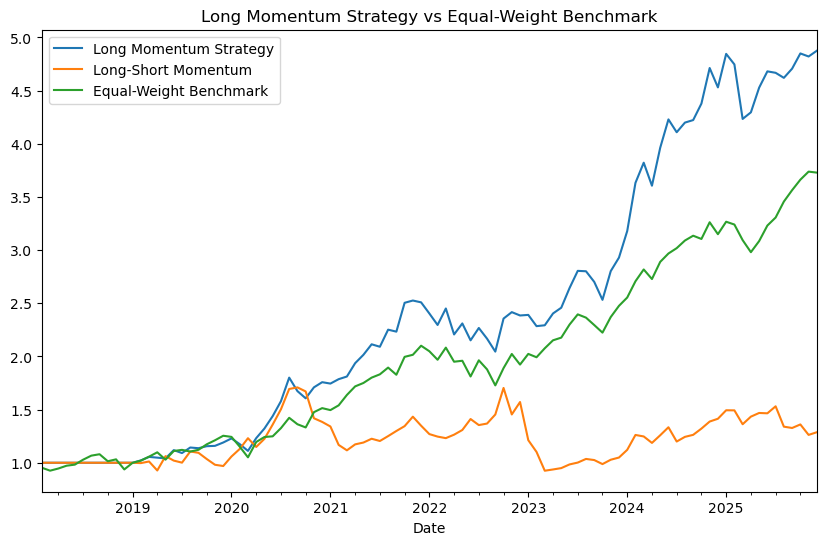

In [50]:
comparison.plot(
    figsize=(10, 6),
    title="Long Momentum Strategy vs Equal-Weight Benchmark"
)

## 15. Latest Selected Stocks

In [ ]:
latest_signals = signals.iloc[-1]

selected_stocks = latest_signals[
    latest_signals
].index

print("Selected stocks:")
print(list(selected_stocks))

## Conclusion

The results show that the long-only momentum strategy outperformed the equal-weight benchmark over the backtest period. This suggests that selecting stocks with the strongest 12–1 momentum added value compared with simply holding all stocks equally.

The long-short momentum strategy performed much more modestly. Although the long portfolio benefited from holding strong-momentum stocks, shorting the weakest-momentum stocks did not add significant value. One possible explanation is that, during a generally rising equity market, even stocks with relatively weak momentum can still generate positive returns, creating losses on the short side.

An important distinction is that the long-only strategy contains substantial market exposure, while the long-short strategy is designed to isolate the momentum factor more directly:

$$ \text{Momentum Factor Return} \approx \text{Return of Winners} - \text{Return of Losers} $$

Therefore, cumulative return alone is not sufficient to evaluate the strategies. A more complete comparison should also consider annualized return, volatility, Sharpe ratio, and maximum drawdown.
